In [1]:
import hoda
import tensorly as tl
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300
from moabb.datasets import *
from mne.decoding import Scaler

tmin = 0
tmax=0.8
fmin=0.5
fmax = 16
sfreq = 32

paradigm = P300(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax)
dataset = BNCI2014_009()
epochs, labels, meta = paradigm.get_data(dataset=dataset, 
                                         subjects=[1],
                                         return_epochs=True)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]

scaler = Scaler(scalings='mean', with_mean=False)
epochs._data = scaler.fit_transform(epochs._data)

<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_types is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.pick_channels_regexp is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
<frozen importlib._bootstrap>:241: FutureWarning: mne.io.pick.channel_type is deprecated will be removed in 1.6, use documented public API instead. If no appropriate public API exists, please open an issue on GitHub.
/usr/local/lib/python3.10/dist-packages/moabb/pipelines/__init__.py:26: ModuleNotFoundError: Tensorflow is not installed. You won't be able to use these MOABB pipelines if you attempt to do so.
  warn(


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
Adding metadata with 3 columns
1728 matching events found
No baseline correction applied


/usr/local/lib/python3.10/dist-packages/moabb/paradigms/base.py:354: RuntimeWarning: Concatenation of Annotations within Epochs is not supported yet. All annotations will be dropped.
  X = mne.concatenate_epochs(X)


In [3]:
epochs

Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.781 s
Baseline,off


In [4]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [5]:
X = epochs.get_data()
y = labels

X.shape

/tmp/ipykernel_3488/2444922706.py:1: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  X = epochs.get_data()


(576, 16, 26)

In [6]:
from hoda.hoda import HODA, f_multiway
import warnings

from hoda.hoda import f_oneway, mode_scatter
from hoda.gpu_opt import combine_pvalues
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from hoda.classification import Vectorize
from sklearn.feature_selection import SelectFwe
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import pandas as pd
from sklearn.preprocessing import StandardScaler


hoda = HODA(
  rank=2,
        max_iter=1024,
        tol=1e-8,
        init ='svd',
        shrinkage='lw',
        toeplitz=(1,),
        obj='rt',
        solver='lanczos',
        taper=False,
        keep_train_info=True,
        verbose=True,
        )

%lprun -f HODA.fit hoda.fit(X,y)
hoda

Initializing factors...
Fitting discriminative Tucker model...


  0%|          | 0/1024 [00:00<?, ?it/s]

Fitted Tucker model of rank (2, 2) ...


HODA(keep_train_info=True, max_iter=1024, rank=2, toeplitz=(1,), verbose=True)

Timer unit: 1e-09 s

Total time: 0.668163 s
File: /project/src/hoda/hoda.py
Function: fit at line 299

Line #      Hits         Time  Per Hit   % Time  Line Contents
   299                                               def fit(self, X, y):
   300                                                   # Setup
   301                                                   # X = tl.tensor(X.copy(), dtype=X.dtype)
   302         1   77005409.0    8e+07     11.5          X = tl.tensor(X, dtype=X.dtype)
   303         1     121948.0 121948.0      0.0          self.classes_, class_counts = np.unique(y, return_counts=True)
   304         1     827245.0 827245.0      0.1          class_counts = tl.tensor(class_counts)
   305         1       3789.0   3789.0      0.0          n_samples, *shape = X.shape
   306         1        676.0    676.0      0.0          order = len(shape)
   307                                           
   308                                                   # Initialize solver
   3

In [7]:
hoda.train_info_

,F_tr,F_rt,mse,update
iteration,,,,
0.0,0.196417,0.003095,0.974802,8.900801e-02
1.0,0.402407,0.005118,0.900212,5.511877e-02
2.0,0.472477,0.007095,0.963101,1.081944e-02
3.0,0.512426,0.006855,0.942836,2.693863e-03
4.0,0.511571,0.007246,0.958778,7.563524e-04
5.0,0.522807,0.007131,0.952886,2.142487e-04
6.0,0.519960,0.007208,0.957069,7.170854e-05
7.0,0.525063,0.007178,0.955317,2.207962e-05
8.0,0.523324,0.007194,0.956512,1.091311e-05


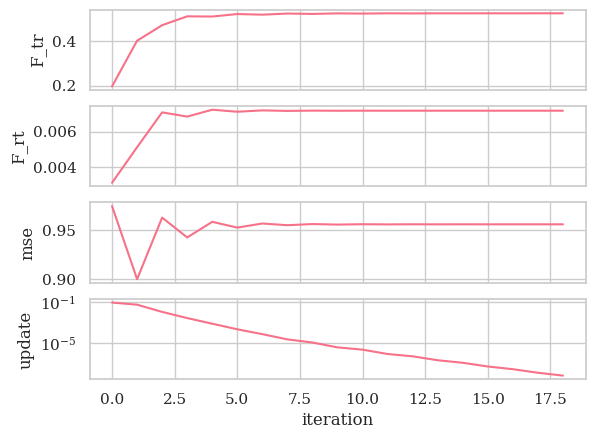

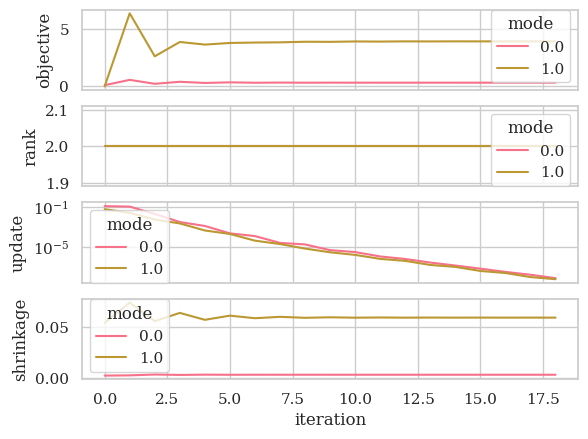

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

if hoda.keep_train_info:
    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_tr', ax=axs[0])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='F_rt', ax=axs[1])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='mse', ax=axs[2])
    #axs[2].set(yscale="log")
    #axs[2].set_ylim([0,None])
    sns.lineplot(data=hoda.train_info_.astype(float), x='iteration', y='update', ax=axs[3])
    axs[3].set(yscale="log")


    fig, axs = plt.subplots(4,1, sharex=True)
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='objective',hue='mode', ax=axs[0])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='rank',hue='mode', ax=axs[1])
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='update',hue='mode', ax=axs[2])
    axs[2].set(yscale="log")
    sns.lineplot(data=hoda.mode_train_info_.astype(float), x='iteration', y='shrinkage',hue='mode', ax=axs[3])


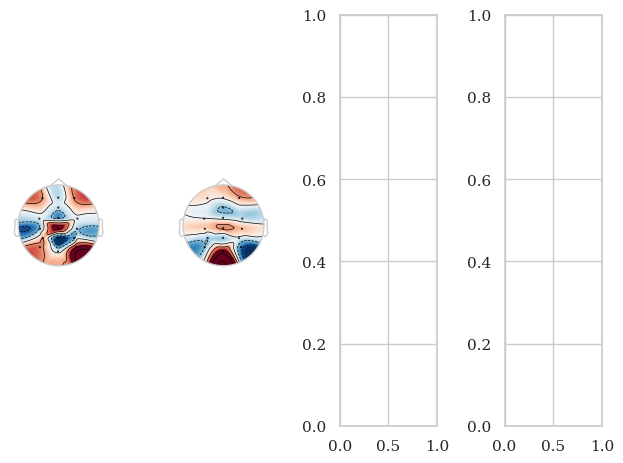

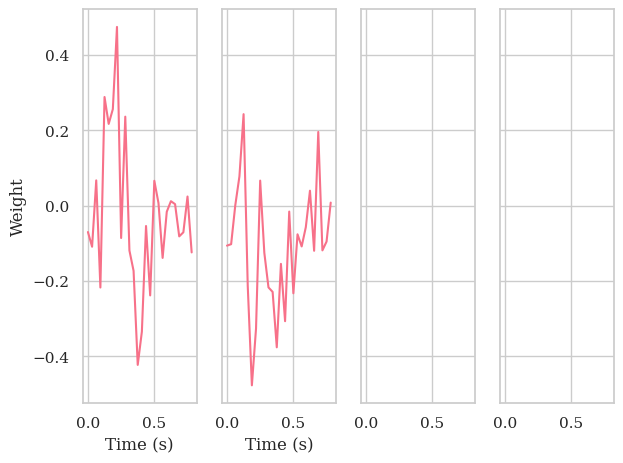

In [9]:

import numpy as np
from mne.viz import plot_topomap
import matplotlib.pyplot as plt
import tensorly as tl


col_wrap = 4

n_col = col_wrap
n_row = int( np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
for i in range(hoda.rank_(0)):
    w = tl.to_numpy(hoda.scalings_[0][:,i])
    plot_topomap(w, epochs.info, axes=axs.flatten()[i], show=False)

n_row = int( np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col,  layout='tight', sharex=True, sharey=True)
for i in range(hoda.rank_(1)):
    w = tl.to_numpy(hoda.scalings_[1][:,i])
    axs.flatten()[i].plot(epochs.times, w)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Weight');


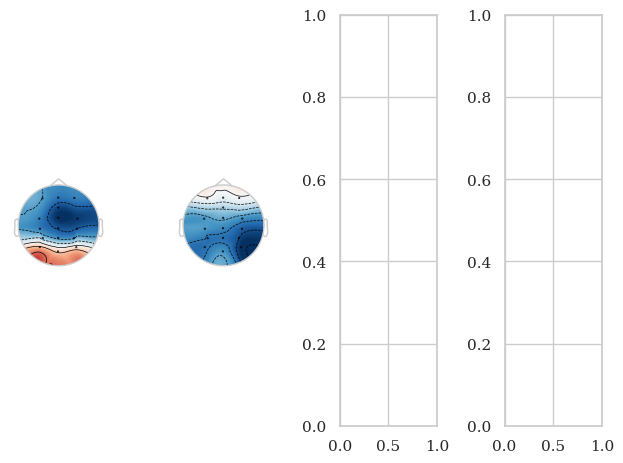

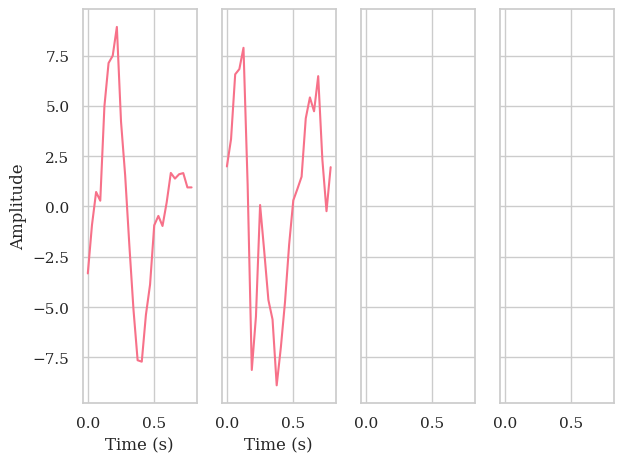

In [10]:

n_row = int(np.ceil(hoda.rank_(0) / col_wrap)) 
fig, axs = plt.subplots(n_row, n_col, layout='tight')
A = hoda.aps_[0]
for i in range(hoda.rank_(0)):
    a = tl.to_numpy(A[:,i])
    plot_topomap(a, epochs.info, axes=axs.flatten()[i], show=False)


n_row = int(np.ceil(hoda.rank_(1) / col_wrap)) 
fig, axs = plt.subplots(
    n_row, n_col, 
    layout='tight', 
    sharex=True,
    sharey=True
)
A = hoda.aps_[1]
for i in range(hoda.rank_(1)):
    a = tl.to_numpy(A[:,i])
    axs.flatten()[i].plot(epochs.times, a)
    axs.flatten()[i].set_xlabel('Time (s)')
    axs.flatten()[i].sharey(axs.flatten()[0])
axs.flatten()[0].set_ylabel('Amplitude');


In [11]:
"""
_, axs = plt.subplots(2,4, layout='constrained', figsize=(14,8))
for k in range(2):
    
    scatter_b = tl.to_numpy(hoda.scatter_b_[k])
    vmax = np.max(np.abs(scatter_b))
    axs[k,0].set_aspect('equal')
    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    
    
    scatter_w = tl.to_numpy(hoda.scatter_w_[k])
    vmax = np.max(np.abs(scatter_w))
    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    
    axs[k,1].set_aspect('equal')


    cov_l= tl.to_numpy(hoda.cov_l_[k])
    vmax = np.max(np.abs(cov_l))
    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    
    axs[k,2].set_aspect('equal')


    cov =  tl.to_numpy(hoda.cov_[k])
    vmax = np.max(np.abs(cov))
    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    
    axs[k,3].set_aspect('equal')

"""

"\n_, axs = plt.subplots(2,4, layout='constrained', figsize=(14,8))\nfor k in range(2):\n    \n    scatter_b = tl.to_numpy(hoda.scatter_b_[k])\n    vmax = np.max(np.abs(scatter_b))\n    axs[k,0].set_aspect('equal')\n    sns.heatmap(scatter_b, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,0])    \n    \n    scatter_w = tl.to_numpy(hoda.scatter_w_[k])\n    vmax = np.max(np.abs(scatter_w))\n    sns.heatmap(scatter_w, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,1])    \n    axs[k,1].set_aspect('equal')\n\n\n    cov_l= tl.to_numpy(hoda.cov_l_[k])\n    vmax = np.max(np.abs(cov_l))\n    sns.heatmap(cov_l, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,2])    \n    axs[k,2].set_aspect('equal')\n\n\n    cov =  tl.to_numpy(hoda.cov_[k])\n    vmax = np.max(np.abs(cov))\n    sns.heatmap(cov, cmap='BrBG', vmin=-vmax, vmax=vmax, ax=axs[k,3])    \n    axs[k,3].set_aspect('equal')\n\n"

In [12]:
"""
for k in range(2):
    sns.heatmap(tl.to_numpy(hoda.scalings_[k].T@ hoda.aps_[k]), center=0)
    plt.show()
"""

'\nfor k in range(2):\n    sns.heatmap(tl.to_numpy(hoda.scalings_[k].T@ hoda.aps_[k]), center=0)\n    plt.show()\n'

In [13]:
Xt = hoda.transform(X)

[[4.07372735e-01 7.48514175e-50]
 [1.39568119e-70 4.80549467e-03]]

[3.80607828e-21 1.60704237e-35]

[1.24932513e-34 7.84906341e-21]


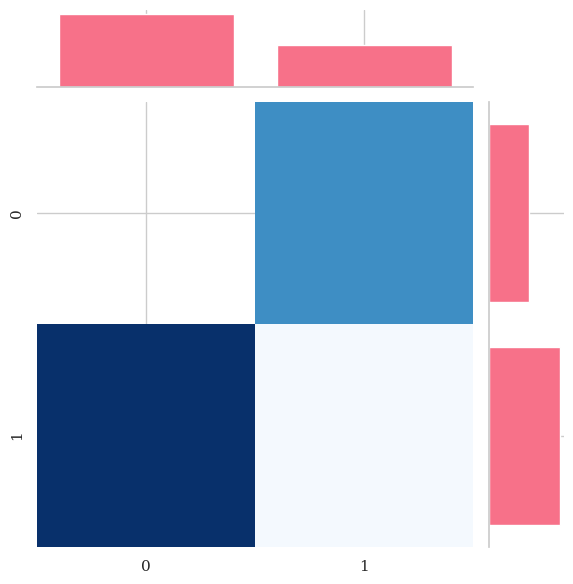

In [14]:
from hoda.hoda import f_multiway
from hoda.gpu_opt import combine_pvalues

F, p = f_oneway(Xt,y)

classes = np.unique(y)
y_like_Xt = tl.zeros_like(Xt)
for ci, c in enumerate(classes):
    y_like_Xt[y==c] = ci


F_sp, p_sp = f_oneway(tl.unfold(Xt, 0+1).T, tl.unfold(y_like_Xt, 0+1).T[:,0])
F_tmp, p_tmp = f_oneway(tl.unfold(Xt, 1+1).T, tl.unfold(y_like_Xt, 1+1).T[:,0])


F_sp = tl.to_numpy(F_sp)
F_tmp = tl.to_numpy(F_tmp)
F = tl.to_numpy(F)
p= tl.to_numpy(p)

g = sns.JointGrid()
sns.heatmap(F, vmin=0, ax=g.ax_joint, mask=p>0.05/p.size,cbar=False, cmap='Blues')
g.ax_marg_x.bar(np.arange(p.shape[1]) + 0.5, F_tmp)
g.ax_marg_y.barh(np.arange(p.shape[0]) + 0.5, F_sp)

print(p)
print()
print(p_sp)
print()
print(p_tmp)

In [15]:
from sklearn.feature_selection import SelectFwe

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))
Xt_flat.shape

(576, 4)

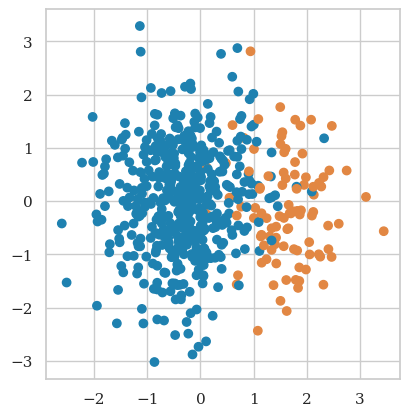

In [16]:

from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

Xt_flat = tl.to_numpy(Xt.reshape((Xt.shape[0], -1)))

if Xt_flat.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt_flat))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')

No projector specified for this dataset. Please consider the method self.add_proj.


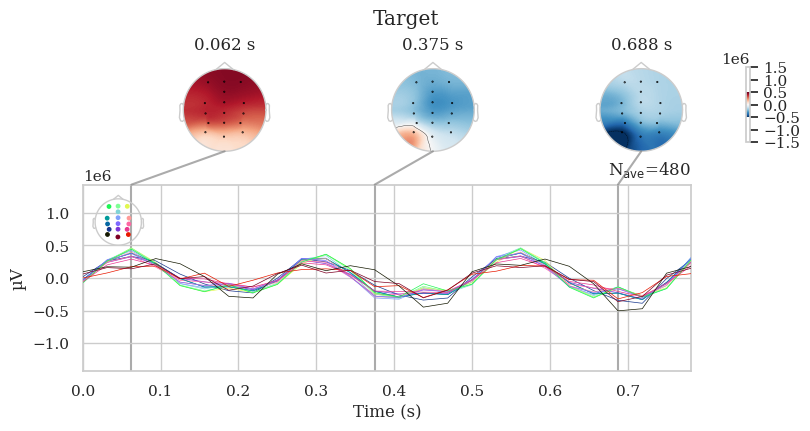

No projector specified for this dataset. Please consider the method self.add_proj.


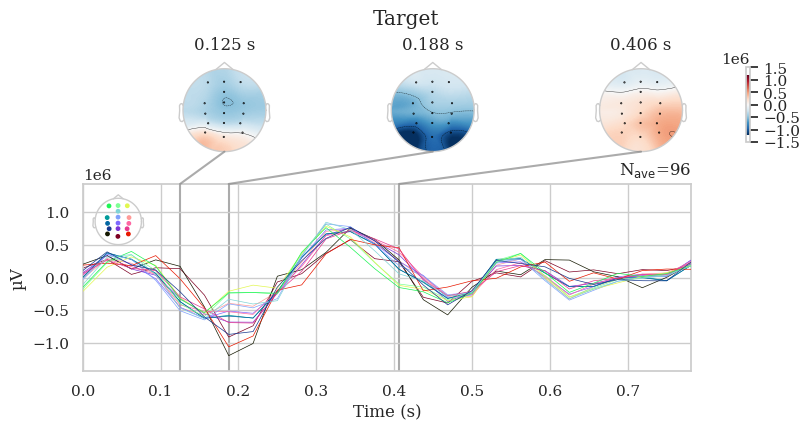

In [17]:
import numpy as np

evokeds = []
vmax=0
for cls in np.unique(labels):
    evoked = epochs[cls].average()
    evokeds.append(evoked)
    vmax= max(vmax, np.max(np.abs(evoked.data))*1.2*1e6)

ts_args=dict(ylim=dict(eeg=[-vmax,vmax]))
joint_args=dict(ts_args=ts_args)

for evoked  in evokeds:
    if len(evoked.ch_names) > 1:
        evoked.plot_joint(title=cls, **joint_args)
    else:
        evoked.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


/tmp/ipykernel_3488/286715887.py:2: FutureWarning: The current default of copy=False will change to copy=True in 1.7. Set the value of copy explicitly to avoid this warning
  epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))


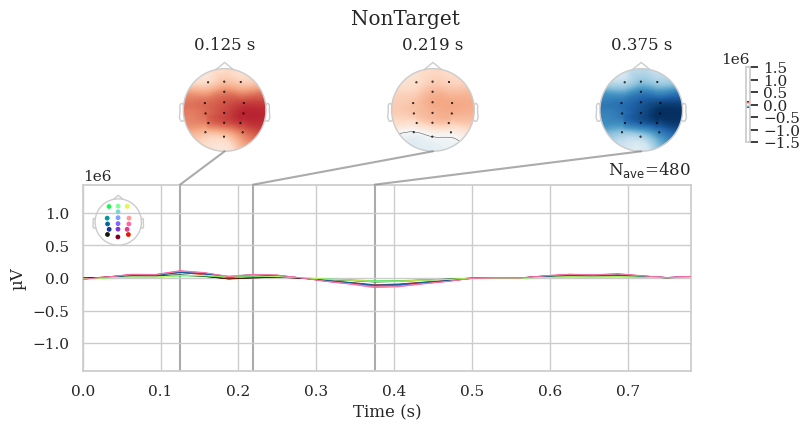

No projector specified for this dataset. Please consider the method self.add_proj.


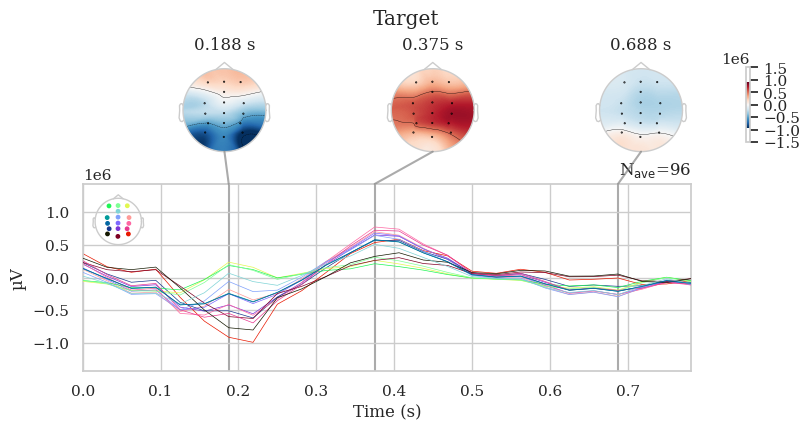

In [18]:
epochs_rec = epochs.copy()
epochs_rec._data = tl.to_numpy(hoda.inv_transform(hoda.transform(epochs.get_data())))
evokeds_rec = []
for cls in np.unique(labels):
    evoked_rec = epochs_rec[cls].average()
    evokeds_rec.append(evoked_rec)
    if len(evoked_rec.ch_names) > 1:
        evoked_rec.plot_joint(title=cls,**joint_args)
    else:
        evoked_rec.plot(**ts_args)

No projector specified for this dataset. Please consider the method self.add_proj.


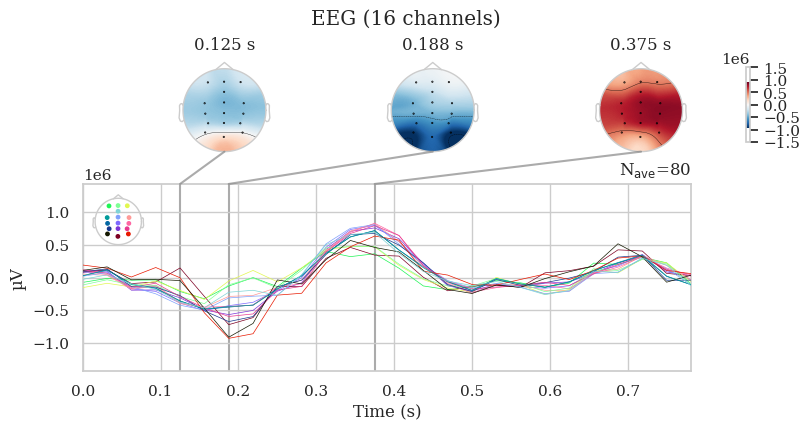

No projector specified for this dataset. Please consider the method self.add_proj.


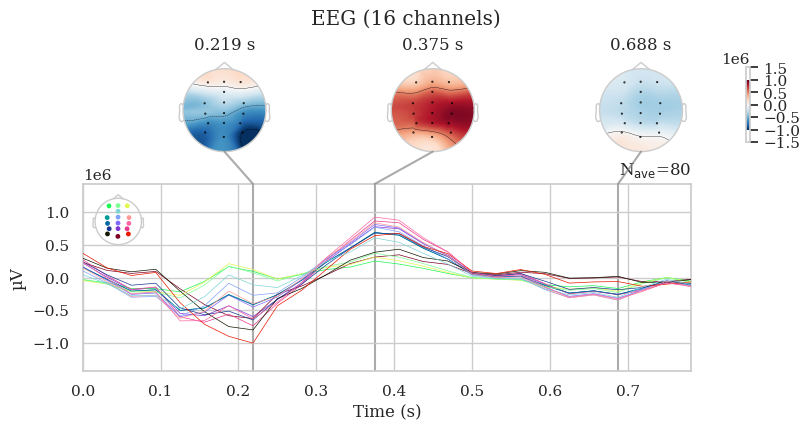

In [19]:
from mne import combine_evoked
contrast = combine_evoked(evokeds, weights=[-1,1])
_ = contrast.plot_joint(**joint_args)
contrast_rec = combine_evoked(evokeds_rec, weights=[-1,1])
_ = contrast_rec.plot_joint(**joint_args)


No projector specified for this dataset. Please consider the method self.add_proj.


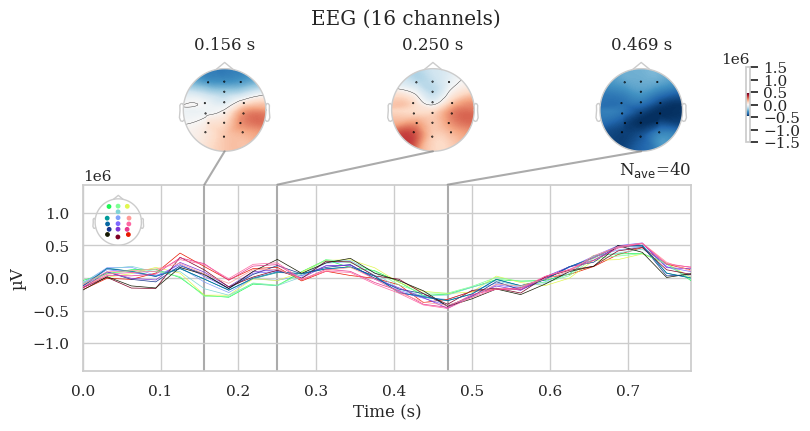

In [20]:
rec_diff = combine_evoked([contrast, contrast_rec], weights=[1,-1])
_ = rec_diff.plot_joint(**joint_args)